### Fraud Detection - Assignment 2 

Hitarth Parikh - 25030242024

In [1]:
# Importing all the necessary libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [23]:
# Reading and Displaying the csv file

fraud_data = pd.read_csv("Fraud Detection Dataset.csv")
print(fraud_data.shape)
fraud_data.head()

(51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [24]:
# Displaying all the columns in the dataset

fraud_data.columns.tolist()
list(fraud_data)

['Transaction_ID',
 'User_ID',
 'Transaction_Amount',
 'Transaction_Type',
 'Time_of_Transaction',
 'Device_Used',
 'Location',
 'Previous_Fraudulent_Transactions',
 'Account_Age',
 'Number_of_Transactions_Last_24H',
 'Payment_Method',
 'Fraudulent']

In [ ]:
# Percentage of missing values in each column before dropping the missing values

missing_percent_before = fraud_data.isnull().mean()*100

print(missing_percent_before)

Transaction_ID                      0.000000
User_ID                             0.000000
Transaction_Amount                  4.941176
Transaction_Type                    0.000000
Time_of_Transaction                 5.003922
Device_Used                         4.849020
Location                            4.994118
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Payment_Method                      4.841176
Fraudulent                          0.000000
dtype: float64


In [27]:
# Dropping all the rows containing missing values

fraud_data=fraud_data.dropna()

In [28]:
# Percentage of missing values in each column after dropping the missing values 

missing_percent = fraud_data.isnull().mean()*100

print(missing_percent)

Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


In [29]:
# Finding the number of duplicate records in the dataset

duplicates = fraud_data.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 688


### Task1: Column wise Duplicate count

In [31]:
# Count duplicate values in each column of the dataset

duplicate_counts = fraud_data.apply(lambda x: x.duplicated().sum())
print(duplicate_counts)

Transaction_ID                        787
User_ID                             35583
Transaction_Amount                   2667
Transaction_Type                    39578
Time_of_Transaction                 39559
Device_Used                         39579
Location                            39575
Previous_Fraudulent_Transactions    39578
Account_Age                         39464
Number_of_Transactions_Last_24H     39569
Payment_Method                      39578
Fraudulent                          39581
dtype: int64


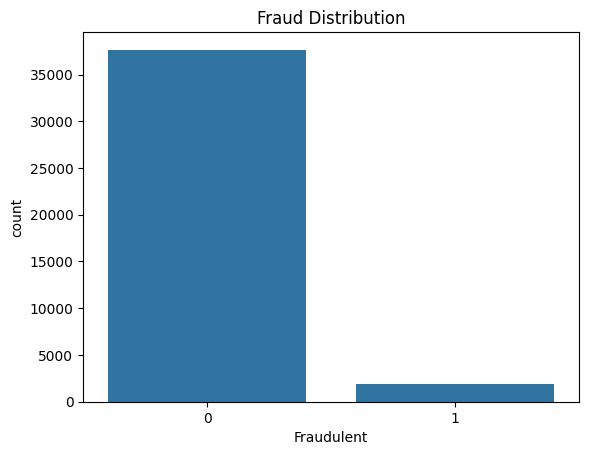

In [9]:
sns.countplot(x="Fraudulent", data=fraud_data)

plt.title("Fraud Distribution")

plt.show()

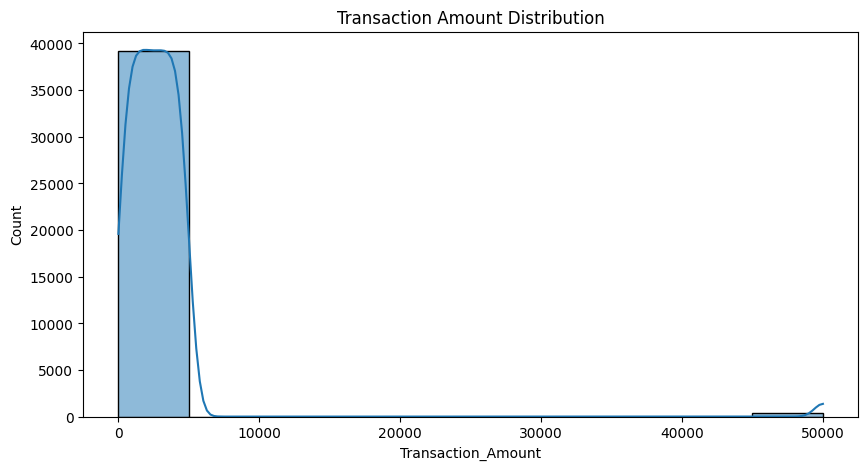

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    fraud_data["Transaction_Amount"],
    bins=10,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

### Task2: Cluster for Payment_Method v/s Fraudulent

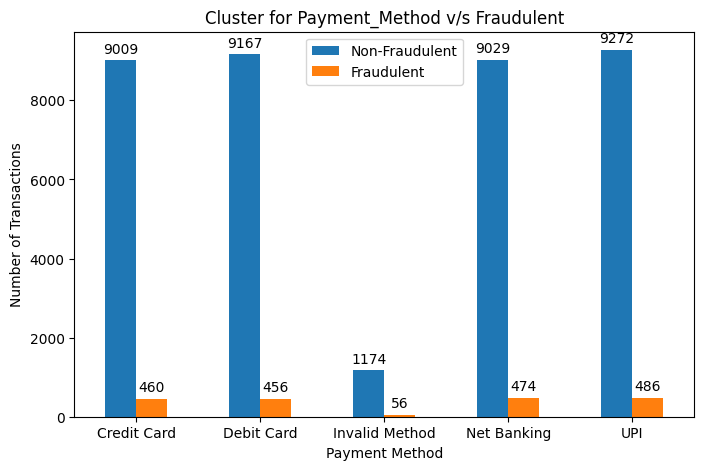

In [35]:
# Create a clustered bar chart showing Fraudulent vs Non-Fraudulent transactions for each payment method

payment_fraud = pd.crosstab(fraud_data['Payment_Method'], fraud_data['Fraudulent'])

ax = payment_fraud.plot(kind='bar', figsize=(8,5))

plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.title('Cluster for Payment_Method v/s Fraudulent')
plt.xticks(rotation=0)
plt.legend(['Non-Fraudulent', 'Fraudulent'])

# Display the count on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.show()

<Axes: >

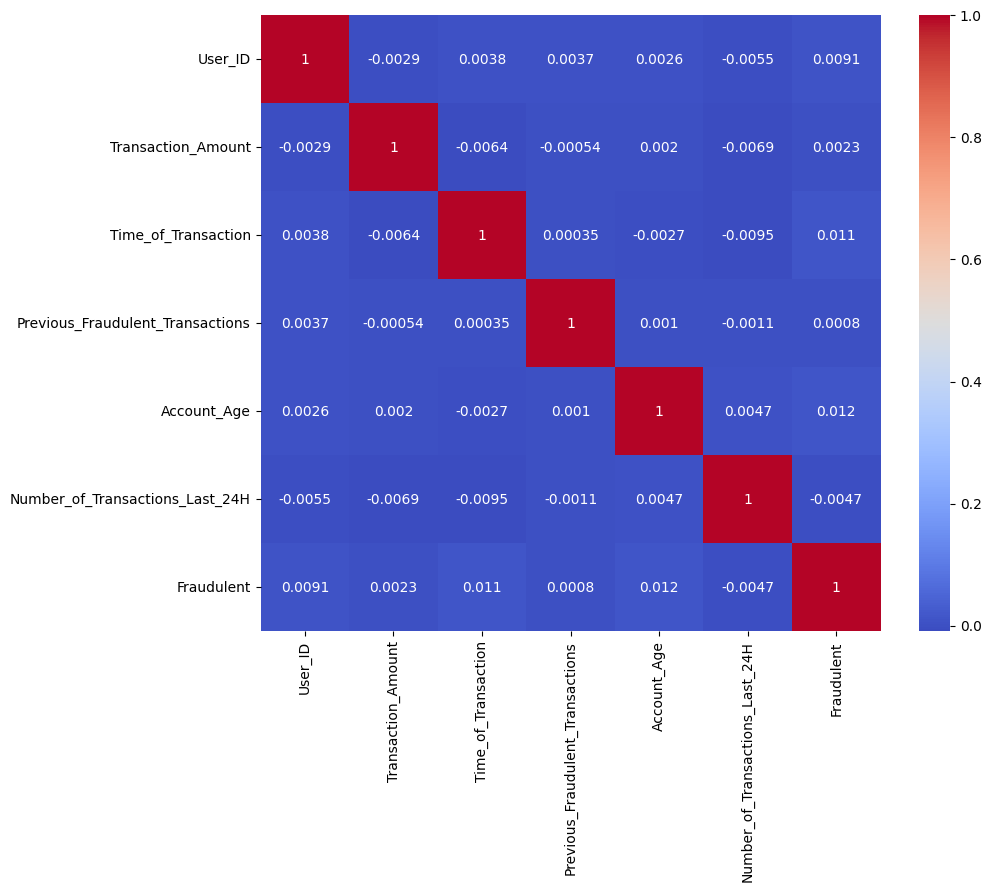

In [10]:
numeric = fraud_data.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(

numeric.corr(),

annot=True,

cmap="coolwarm"

)

# Outlier 

Text(0.5, 1.0, 'Transaction Amount Boxplot')

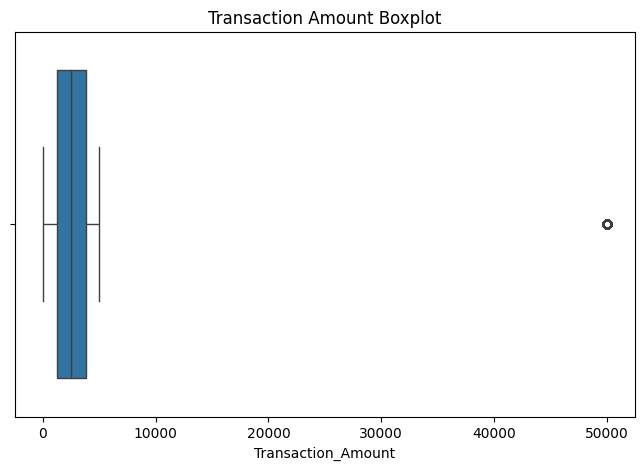

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=fraud_data["Transaction_Amount"]
)

plt.title("Transaction Amount Boxplot")

In [13]:
Q1 = fraud_data["Transaction_Amount"].quantile(0.25)

Q3 = fraud_data["Transaction_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR


outliers = fraud_data[
    (fraud_data["Transaction_Amount"] < lower) |
    (fraud_data["Transaction_Amount"] > upper)
]

#Lower_outlier= df[df["Transaction_Amount"] < lower]

#Lower_outlier.head()

#upper_outlier= df[df["Transaction_Amount"] < upper]

#upper_outlier.head()
#upper_outlier.shape
#Lower_outlier.shape
print(outliers.shape)
#outliers.head()

(416, 12)


### Task 3: Find Outlires from: Time_of_Transaction, and create graph

In [51]:
# Calculate Q1, Q3 and IQR
Q1 = fraud_data['Time_of_Transaction'].quantile(0.25)
Q3 = fraud_data['Time_of_Transaction'].quantile(0.75)

IQR = Q3 - Q1

# Calculate outlier boundaries
lower_bound = Q1 - 0.49 * IQR
upper_bound = Q3 + 0.49 * IQR

# Identify outliers
outliers = fraud_data[
    (fraud_data['Time_of_Transaction'] < lower_bound) |
    (fraud_data['Time_of_Transaction'] > upper_bound)
]

print("Number of Outliers:", len(outliers))
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Number of Outliers: 1603
Lower Bound: -0.8799999999999999
Upper Bound: 22.88


[23. 23. 23. ... 23. 23. 23.]


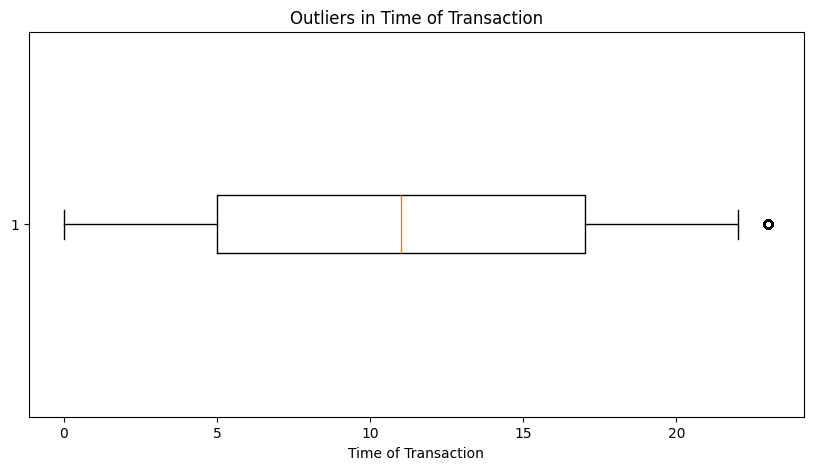

In [56]:
print(outliers['Time_of_Transaction'].values)

plt.figure(figsize=(10, 5))

plt.boxplot(
    fraud_data['Time_of_Transaction'],
    whis=0.49,
    vert=False,
    flierprops=dict(marker='o', markersize=6)
)

plt.xlabel('Time of Transaction')
plt.title('Outliers in Time of Transaction')

plt.show()

### Task 4: Identify Uncommon/Common Value/s

In [58]:
# Identify the frequency of common and uncommon values for all categorical columns

columns = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

for col in columns:
    print(f"\n{col}:")
    print(fraud_data[col].value_counts())


Transaction_Type:
Transaction_Type
Bank Transfer      8012
Bill Payment       7963
ATM Withdrawal     7890
POS Payment        7871
Online Purchase    7847
Name: count, dtype: int64

Device_Used:
Device_Used
Desktop           12835
Tablet            12777
Mobile            12734
Unknown Device     1237
Name: count, dtype: int64

Location:
Location
Boston           5045
Seattle          4997
New York         4963
Los Angeles      4945
Chicago          4933
San Francisco    4928
Miami            4895
Houston          4877
Name: count, dtype: int64

Payment_Method:
Payment_Method
UPI               9758
Debit Card        9623
Net Banking       9503
Credit Card       9469
Invalid Method    1230
Name: count, dtype: int64


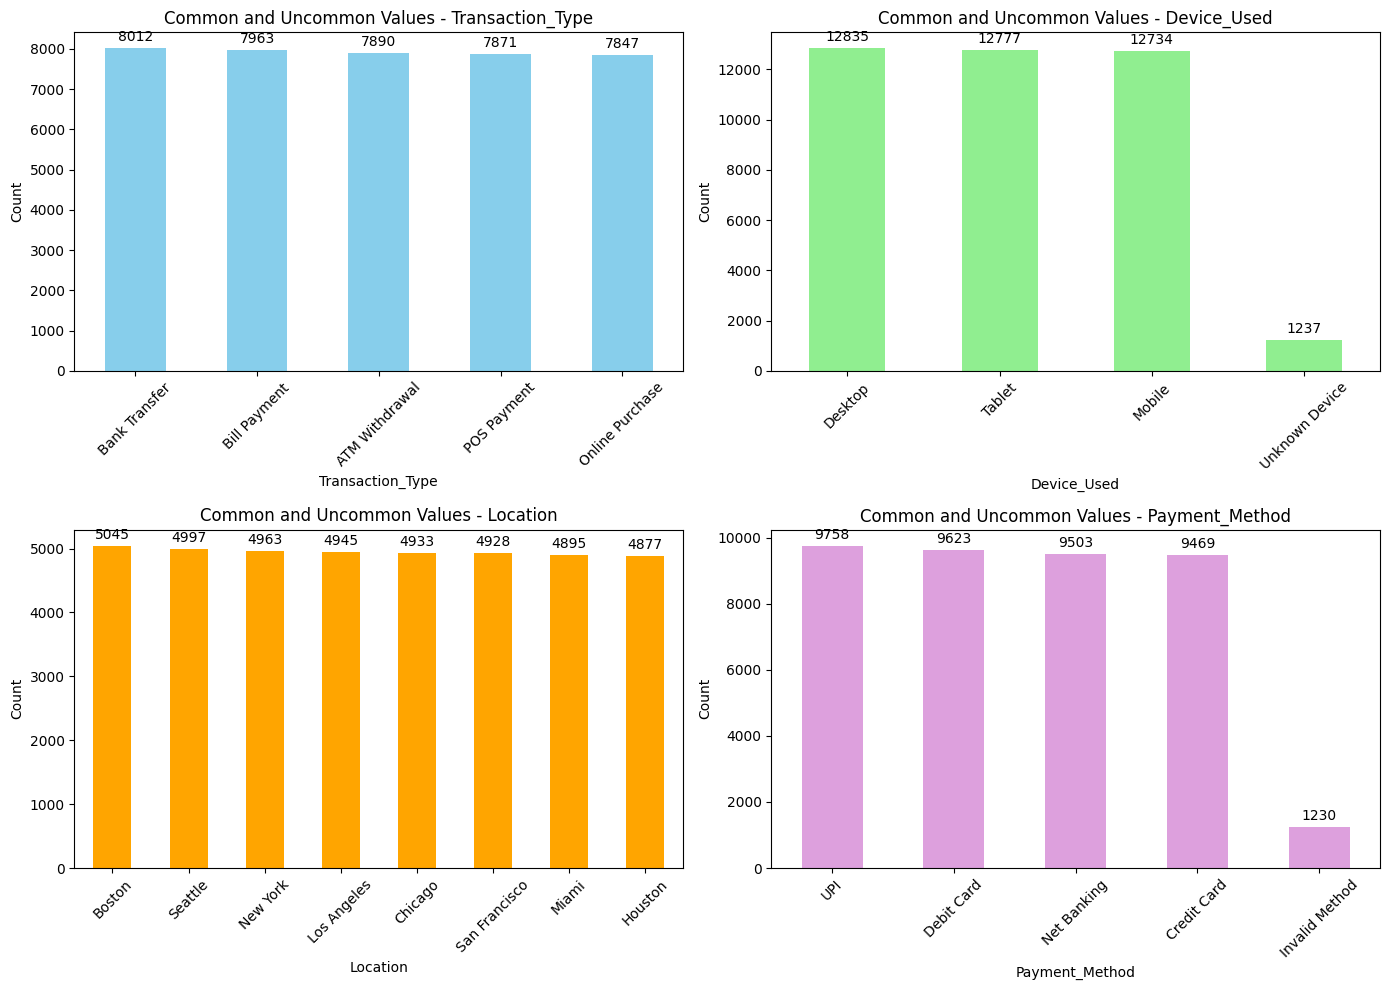

In [63]:
columns = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

colors = ['skyblue', 'lightgreen', 'orange', 'plum']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color in zip(axes.flatten(), columns, colors):
    counts = fraud_data[col].value_counts()
    
    counts.plot(kind='bar', ax=ax, color=color)
    
    ax.set_title(f'Common and Uncommon Values - {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    # Display count on top of each bar
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

In [15]:
features = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]


In [16]:
from sklearn.preprocessing import StandardScaler

X = fraud_data[features]
#X=X.dropna()
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=15
)

labels = dbscan.fit_predict(X_scaled)

In [18]:
fraud_data["Cluster"] = labels
#df.head()
fraud_data["Cluster"].value_counts()

Cluster
 0    39167
 1      408
-1        8
Name: count, dtype: int64

### Task 5: Identify Anomalies with -1 (for different feature set)

In [64]:
# Count the number of -1 values in each column
minus_one_counts = (fraud_data == -1).sum()

print(minus_one_counts)

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


In [65]:
# Identify columns containing -1 anomalies
minus_one_counts = (fraud_data == -1).sum()

anomalies = minus_one_counts[minus_one_counts > 0]

print("Features containing -1:")
print(anomalies)

Features containing -1:
Series([], dtype: int64)


In [19]:
suspicious = fraud_data[fraud_data["Cluster"] == -1]

print(suspicious.head())

      Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
317             T318     4681             49997.8     Bill Payment   
8146           T8147     1640             49997.8     Bill Payment   
15441         T15442     4030             49997.8    Bank Transfer   
19824         T19825     2206             49997.8  Online Purchase   
22058         T22059     3612             49997.8    Bank Transfer   

       Time_of_Transaction Device_Used     Location  \
317                    0.0      Mobile      Houston   
8146                  17.0      Tablet  Los Angeles   
15441                 20.0     Desktop      Seattle   
19824                 14.0      Mobile        Miami   
22058                 20.0      Tablet     New York   

       Previous_Fraudulent_Transactions  Account_Age  \
317                                   4            4   
8146                                  4            7   
15441                                 0            5   
19824                   

### Task 6: Create Graphs for Anomalies

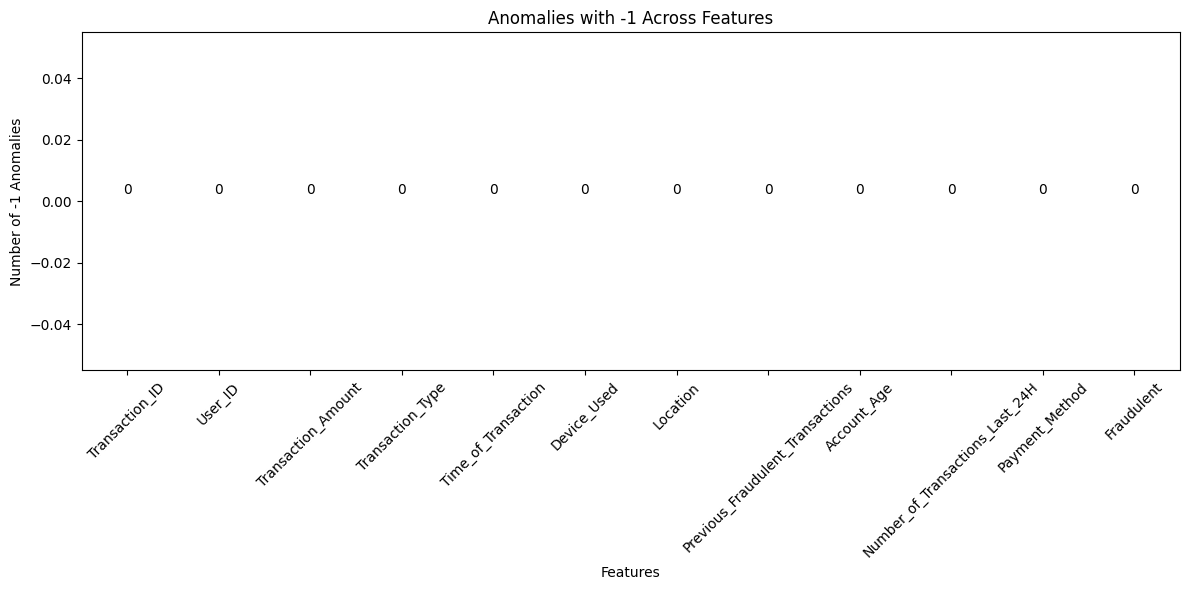

In [67]:
# Count -1 anomalies in each column
minus_one_counts = (fraud_data == -1).sum()

# Create graph
plt.figure(figsize=(12, 6))

ax = minus_one_counts.plot(kind='bar')

plt.xlabel('Features')
plt.ylabel('Number of -1 Anomalies')
plt.title('Anomalies with -1 Across Features')
plt.xticks(rotation=45)

# Display count on top of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

In [20]:
x_attr = "Transaction_Amount"   
y_attr = "Previous_Fraudulent_Transactions"          


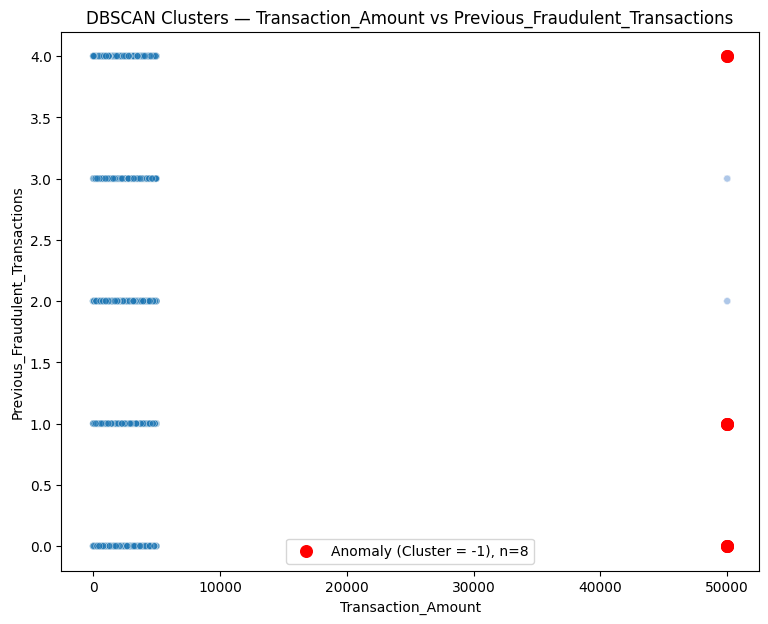

In [21]:
non_noise = fraud_data[fraud_data["Cluster"] != -1]
noise = fraud_data[fraud_data["Cluster"] == -1]

sample_size = min(3000, len(non_noise))
plot_sample = non_noise.sample(n=sample_size, random_state=42)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=plot_sample,
    x=x_attr, y=y_attr,
    hue="Cluster",
    palette="tab20",
    alpha=0.6, s=25,
    legend=False
)

plt.scatter(
    noise[x_attr], noise[y_attr],
    c="red", marker="o", s=70,
    label=f"Anomaly (Cluster = -1), n={len(noise)}"
)

plt.xlabel(x_attr)
plt.ylabel(y_attr)
plt.title(f"DBSCAN Clusters — {x_attr} vs {y_attr}")
plt.legend()
plt.show()
